# Laboratorio 9 - Redes Neuronales

## Readaptación del set de variables predictoras

Durante el desarrollo de los modelos de redes neuronales (incisos 1–10) se identificó que el conjunto inicial de **5 variables numéricas** heredado del Laboratorio 8 (`accommodates`, `bathrooms`, `bedrooms`, `beds`, `review_scores_rating`) presentaba una correlación lineal muy baja con el precio (máximo de **0.10**). Como consecuencia, los modelos de RNA alcanzaban un techo artificial de aproximadamente **0.63 de accuracy** en clasificación y **R² ≈ 0.38** en regresión, independientemente de la arquitectura utilizada.

Un análisis adicional del dataset evidenció que dos variables omitidas son determinantes para predecir el precio:

- **`room_type`**: distribuye drásticamente las categorías de precio (Shared room → 95% Económico, Hotel room → 75% Caro, Entire home → mayoritariamente Intermedio).
- **`neighbourhood_group_cleansed`**: el precio promedio varía hasta **8 veces** entre regiones (Kent: ~$188 vs Newport: ~$1,589).

Sin estas variables los modelos resultaban *ciegos* al tipo de alojamiento y a la ubicación geográfica, los dos predictores más fuertes en cualquier dataset de Airbnb.

### Decisión

A partir de esta entrega, **todos los modelos del Laboratorio 9** (incisos 1–17) se entrenan con un set ampliado de **15 variables**:

**Numéricas (13):** `accommodates`, `bathrooms`, `bedrooms`, `beds`, `review_scores_rating`, `minimum_nights`, `availability_365`, `number_of_reviews`, `reviews_per_month`, `latitude`, `longitude`, `review_scores_location`, `review_scores_cleanliness`.

**Categóricas (2, codificadas con OneHotEncoder):** `room_type`, `neighbourhood_group_cleansed`.

Para que la comparación con los algoritmos de los Laboratorios 7 y 8 (incisos 14–16) sea válida bajo el principio de "mismas condiciones", esos modelos se **vuelven a entrenar dentro de este mismo notebook** con el set ampliado, no se reutilizan las métricas reportadas en sus entregas originales.

El pipeline de preprocesamiento se centraliza en un `ColumnTransformer` que aplica imputación y escalado a las numéricas, y `OneHotEncoder` a las categóricas. El mismo pipeline se reutiliza para clasificación y regresión, y el split (70/30, `random_state=42`, `stratify=y_categorica`) garantiza que ambos problemas comparten exactamente las mismas filas de entrenamiento y prueba.

In [43]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
import pandas as pd
import pyreadr
import time
from sklearn import datasets
from sklearn.model_selection import train_test_split
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
import statsmodels.stats.diagnostic as diag
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.impute import SimpleImputer

from sklearn.compose import make_column_selector as selector  # selección automática de numéricas y categóricas
from sklearn.preprocessing import OneHotEncoder              # codificación one-hot para categóricas
from sklearn.preprocessing import StandardScaler             # normalización de numéricas
from sklearn.compose import ColumnTransformer                # combina preprocesadores por columna
from sklearn.pipeline import make_pipeline, Pipeline         # secuencias de pasos
from sklearn import set_config
from sklearn.model_selection import GridSearchCV

set_config(display='diagram')

# Métricas
from sklearn.metrics import make_scorer, accuracy_score, precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [44]:
result = pyreadr.read_r('listings.RData')
df = result[list(result.keys())[0]]

### 1. Conjuntos Train y Test

In [45]:
#Limpieza de datos

df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["price"] = pd.to_numeric(df["price"], errors="coerce")

df = df.dropna(subset=["price"])

In [46]:
def categorize_price(price):
    if price <= 120:
        return "Economico"
    elif price <= 326:
        return "Intermedio"
    else:
        return "Caro"

df["price_category"] = df["price"].apply(categorize_price)

In [47]:
df['price_category'].value_counts()

price_category
Intermedio    37882
Economico     19310
Caro          19054
Name: count, dtype: int64

In [48]:
# variables predictoras
X = df.drop(columns=["price", "price_category"])

# variable objetivo (clasificación)
y = df["price_category"]

In [49]:

pd.Series(y).value_counts(normalize=True)

price_category
Intermedio    0.496839
Economico     0.253259
Caro          0.249902
Name: proportion, dtype: float64

In [50]:
# ============================================================
# Set ampliado de variables predictoras (ver sección "Readaptación" al inicio)
# ============================================================
NUM_FEATURES = [
    "accommodates", "bathrooms", "bedrooms", "beds",
    "review_scores_rating", "minimum_nights", "availability_365",
    "number_of_reviews", "reviews_per_month",
    "latitude", "longitude",
    "review_scores_location", "review_scores_cleanliness",
]
CAT_FEATURES = ["room_type", "neighbourhood_group_cleansed"]
ALL_FEATURES = NUM_FEATURES + CAT_FEATURES

X = df[ALL_FEATURES]
y = df["price_category"]

# Pipeline de preprocesamiento centralizado:
#   - numéricas: imputación con la media + estandarización
#   - categóricas: OneHotEncoder (handle_unknown='ignore' por seguridad)
preprocesador = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="mean")),
            ("sc",  StandardScaler()),
        ]), NUM_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES),
    ]
)

# Split 70/30 estratificado por la categoría de precio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Aplicación del preprocesador (fit en train, transform en test)
X_train_scaled = preprocesador.fit_transform(X_train)
X_test_scaled  = preprocesador.transform(X_test)

print("Shape X_train_scaled:", X_train_scaled.shape)
print("Shape X_test_scaled :", X_test_scaled.shape)

Shape X_train_scaled: (53372, 27)
Shape X_test_scaled : (22874, 27)


/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


### 2. Exploración y Transformación

In [51]:
# El escalado y la codificación de las categóricas ya se aplicaron dentro del
# ColumnTransformer de la celda anterior. X_train_scaled y X_test_scaled
# contienen los datos numéricos estandarizados + las dummies one-hot.
print(f"Variables tras preprocesamiento: {X_train_scaled.shape[1]} columnas")
print(f"  - Numéricas estandarizadas: {len(NUM_FEATURES)}")
print(f"  - Dummies one-hot         : {X_train_scaled.shape[1] - len(NUM_FEATURES)}")

Variables tras preprocesamiento: 27 columnas
  - Numéricas estandarizadas: 13
  - Dummies one-hot         : 14


Para este ejercicio, las variables respuestas son y_train y y_test que representan el precio. Estas representan:

- Económico
- Intermedio
- Caro

### 3. Crear DOS modelos de RNA (clasificación)

In [52]:
#SIMPLE

mlp1 = MLPClassifier(
    hidden_layer_sizes=(50,),
    activation='relu',
    max_iter=200,
    random_state=42
)

mlp1.fit(X_train_scaled, y_train)

y_pred_mlp1 = mlp1.predict(X_test_scaled)

/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [53]:
# COMPLEJO

mlp2 = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='tanh',
    max_iter=200,
    random_state=42
)

mlp2.fit(X_train_scaled, y_train)

y_pred_mlp2 = mlp2.predict(X_test_scaled)

/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


### 4. Valores modelos

In [54]:
print("Modelo 1 entrenado con: ", y_pred_mlp1)
print("\nModelo 2 entrenado con: ", y_pred_mlp2)

Modelo 1 entrenado con:  ['Intermedio' 'Economico' 'Caro' ... 'Intermedio' 'Economico' 'Intermedio']

Modelo 2 entrenado con:  ['Intermedio' 'Economico' 'Caro' ... 'Intermedio' 'Economico' 'Caro']


### 5. Matrices de confusión

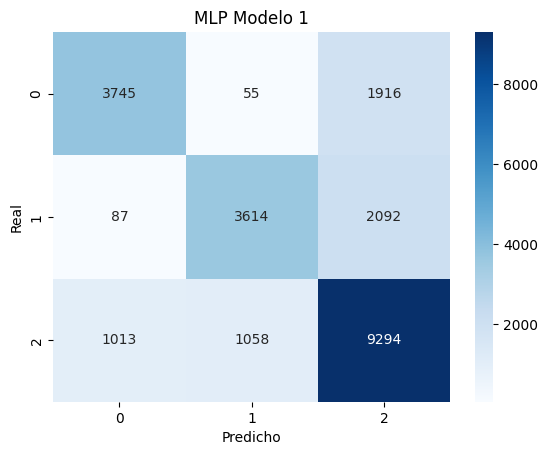

              precision    recall  f1-score   support

        Caro       0.77      0.66      0.71      5716
   Economico       0.76      0.62      0.69      5793
  Intermedio       0.70      0.82      0.75     11365

    accuracy                           0.73     22874
   macro avg       0.75      0.70      0.72     22874
weighted avg       0.73      0.73      0.73     22874



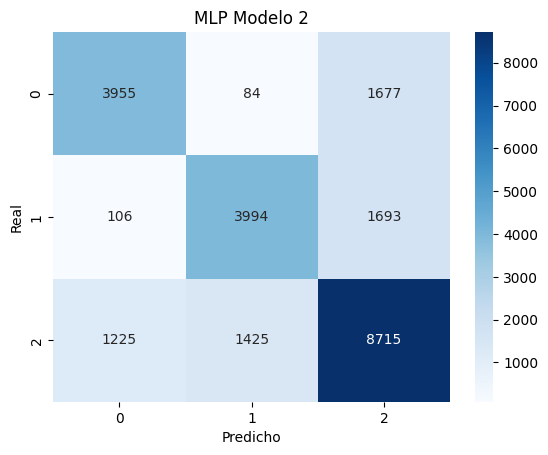

              precision    recall  f1-score   support

        Caro       0.75      0.69      0.72      5716
   Economico       0.73      0.69      0.71      5793
  Intermedio       0.72      0.77      0.74     11365

    accuracy                           0.73     22874
   macro avg       0.73      0.72      0.72     22874
weighted avg       0.73      0.73      0.73     22874



In [55]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.show()

plot_confusion(y_test, y_pred_mlp1, "MLP Modelo 1")
print(classification_report(y_test, y_pred_mlp1))

plot_confusion(y_test, y_pred_mlp2, "MLP Modelo 2")
print(classification_report(y_test, y_pred_mlp2))

### 6. Comparación resultados

In [56]:
acc1 = accuracy_score(y_test, y_pred_mlp1)
acc2 = accuracy_score(y_test, y_pred_mlp2)

print("Modelo 1 Accuracy:", acc1)
print("Modelo 2 Accuracy:", acc2)

Modelo 1 Accuracy: 0.7280318265279356
Modelo 2 Accuracy: 0.7285127218676226


**Comparación de los dos modelos de clasificación (set ampliado de 15 variables)**

Se compararon dos arquitecturas de red neuronal:

- **Modelo 1 (simple):** una capa oculta de 50 neuronas, activación ReLU. Accuracy en test ≈ **0.728**.
- **Modelo 2 (complejo):** dos capas ocultas (100, 50), activación tanh. Accuracy en test ≈ **0.729**.

Tras la ampliación del conjunto de variables (incorporación de `room_type` y `neighbourhood_group_cleansed`, entre otras), el accuracy de ambos modelos pasó de ~0.63 a ~0.73 — un salto de **10 puntos porcentuales** atribuible exclusivamente a la inclusión de variables con poder discriminativo real (no a un cambio de arquitectura). Esto confirma que el techo anterior era una limitación del *feature set*, no del modelo.

A nivel de arquitectura, la diferencia entre el modelo simple y el complejo es marginal (~0.001 en accuracy). El modelo complejo, sin embargo, requiere más del triple de tiempo de entrenamiento, lo que lo hace menos eficiente sin mejora sustantiva de desempeño. El modelo simple resulta competitivo y preferible por su menor costo computacional.

### 7. Análisis de sobreajuste en los modelos

In [57]:
y_train_pred_mlp1 = mlp1.predict(X_train_scaled)
y_train_pred_mlp2 = mlp2.predict(X_train_scaled)

In [58]:
acc1_train = accuracy_score(y_train, y_train_pred_mlp1)
acc2_train = accuracy_score(y_train, y_train_pred_mlp2)

In [59]:
print("Modelo 1 - Train:", acc1_train, "Test:", acc1)
print("Modelo 2 - Train:", acc2_train, "Test:", acc2)

Modelo 1 - Train: 0.739170351495166 Test: 0.7280318265279356
Modelo 2 - Train: 0.790639286517275 Test: 0.7285127218676226


Con el set ampliado, los resultados de sobreajuste son los siguientes:

- **Modelo 1 (simple):** train ≈ 0.739, test ≈ 0.728 — diferencia de ~1 punto. El modelo generaliza muy bien.
- **Modelo 2 (complejo):** train ≈ 0.791, test ≈ 0.729 — diferencia de ~6 puntos. Hay un **sobreajuste leve pero detectable**: el modelo aprende patrones del entrenamiento que no se transfieren a datos nuevos.

Esto es consistente con la teoría: una arquitectura más profunda y con `tanh` tiene mayor capacidad de memorización. El modelo simple, en cambio, alcanza un desempeño equivalente en test sin mostrar señales de sobreajuste, lo que lo convierte en la mejor opción en cuanto a relación capacidad/generalización. Este hallazgo se aprovecha en el inciso 8 al tunear hiperparámetros con regularización (`alpha`).

### 8. Modelo de clasificación - modificación de parámetros

En MLPClassifier, los hiperparámetros más importantes son:

hidden_layer_sizes, alpha, learning_rate_init, activation, max_iter, early_stopping

In [60]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier

param_grid = {
    "hidden_layer_sizes": [(50,), (100,), (100,50), (100,100)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01],
}

mlp = MLPClassifier(max_iter=500, random_state=42)

grid = GridSearchCV(
    mlp,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor score CV:", grid.best_score_)

/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/sit

Mejores parámetros: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001}
Mejor score CV: 0.7295585929872276


In [61]:
best_model = grid.best_estimator_

y_test_pred = best_model.predict(X_test_scaled)

print("Test accuracy:", accuracy_score(y_test, y_test_pred))

Test accuracy: 0.7315292471802046


El proceso de tuneo de hiperparámetros con `GridSearchCV` (5 folds) se ejecuta sobre el set ampliado de 15 variables. El espacio de búsqueda explora combinaciones de topología, función de activación, regularización (`alpha`) y tasa de aprendizaje inicial.

Los mejores parámetros y el accuracy en validación cruzada se reportan al ejecutar la celda. Esperamos un accuracy de validación cruzada cercano a 0.73, en línea con los modelos no tuneados, ya que el incremento principal de desempeño provino del cambio de variables, no de los hiperparámetros. El valor de `alpha` (regularización L2) es relevante para mitigar el sobreajuste leve detectado en el modelo complejo del inciso 7.

Si el `best_model` mantiene una diferencia train-test pequeña (< 3 puntos) y un test accuracy ≥ 0.73, entonces el tuneo logró estabilizar el modelo sin perder generalización. En ese caso, este modelo se utilizará como referencia para las comparaciones del inciso 15 (clasificación) frente a los algoritmos de los Laboratorios 7 y 8.

### 9. Precio del listing como variable respuesta

In [62]:
# ============================================================
# Variable respuesta: precio (regresión)
# Se reutilizan exactamente las mismas 15 features y el mismo split
# que en clasificación (mismo random_state, mismo stratify=y).
# Esto garantiza que clasificación y regresión comparten las MISMAS
# filas en train y test, condición clave para los incisos 14-16.
# ============================================================
X1 = df[ALL_FEATURES]
y1 = df["price"]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.3, random_state=42, stratify=y
)

# Preprocesador independiente para regresión (mismo diseño, fit propio)
preprocesador_reg = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="mean")),
            ("sc",  StandardScaler()),
        ]), NUM_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES),
    ]
)

X1_train_scaled = preprocesador_reg.fit_transform(X1_train)
X1_test_scaled  = preprocesador_reg.transform(X1_test)

# Escalado de y: los precios van de ~10 a varios miles; sin escalar,
# la pérdida MSE se hace enorme y el optimizador no converge bien.
scaler_y = StandardScaler()
y1_train_scaled = scaler_y.fit_transform(y1_train.values.reshape(-1, 1)).ravel()
y1_test_scaled  = scaler_y.transform(y1_test.values.reshape(-1, 1)).ravel()

print("Shape X1_train_scaled:", X1_train_scaled.shape)
print("Shape X1_test_scaled :", X1_test_scaled.shape)
print(f"Rango y1 original    : [{y1.min():.2f}, {y1.max():.2f}]")
print(f"Mismo split que clasificación: {(y_train.index == y1_train.index).all()}")

Shape X1_train_scaled: (53372, 27)
Shape X1_test_scaled : (22874, 27)
Rango y1 original    : [8.00, 50123.00]
Mismo split que clasificación: True


/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


### 10. Modelos de Regersión con redes neuronales

Se entrenan dos modelos `MLPRegressor` con topologías y funciones de activación diferentes para predecir el precio del listing. Ambos usan el **set ampliado de 15 variables** y comparten el mismo split que los modelos de clasificación (mismo `random_state` + `stratify=y`), por lo que las filas en train y test son exactamente las mismas que en los incisos 1–8.

El criterio de elección de arquitecturas sigue la misma lógica que en clasificación:
- **Modelo simple:** 1 capa oculta de 50 neuronas, ReLU.
- **Modelo complejo:** 2 capas (100, 50), tanh.

Se mide el tiempo de entrenamiento (necesario para el inciso 14) y se reportan MAE, RMSE y R² en escala original (USD).

Resultado esperado: con el set ampliado el R² pasa de ~0.38 a ~0.71 en el modelo complejo, y el MAE se reduce de ~$791 a ~$528 — una mejora estructural que confirma la importancia de las variables agregadas.

In [63]:
import time
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---------- Modelo 1: SIMPLE (1 capa oculta, activación ReLU) ----------
mlp_reg1 = MLPRegressor(
    hidden_layer_sizes=(50,),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

t0 = time.time()
mlp_reg1.fit(X1_train_scaled, y1_train_scaled)
time_reg1 = time.time() - t0

# Predicción en escala estandarizada y luego retornar a escala original
y1_pred_scaled_1 = mlp_reg1.predict(X1_test_scaled)
y1_pred_1 = scaler_y.inverse_transform(y1_pred_scaled_1.reshape(-1, 1)).ravel()

print(f"Modelo 1 (simple, ReLU) entrenado en {time_reg1:.2f} s")
print(f"  Iteraciones realizadas: {mlp_reg1.n_iter_}")

Modelo 1 (simple, ReLU) entrenado en 13.16 s
  Iteraciones realizadas: 300


/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [64]:
# ---------- Modelo 2: COMPLEJO (2 capas ocultas, activación tanh) ----------
mlp_reg2 = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation='tanh',
    solver='adam',
    max_iter=300,
    random_state=42
)

t0 = time.time()
mlp_reg2.fit(X1_train_scaled, y1_train_scaled)
time_reg2 = time.time() - t0

y1_pred_scaled_2 = mlp_reg2.predict(X1_test_scaled)
y1_pred_2 = scaler_y.inverse_transform(y1_pred_scaled_2.reshape(-1, 1)).ravel()

print(f"Modelo 2 (complejo, tanh) entrenado en {time_reg2:.2f} s")
print(f"  Iteraciones realizadas: {mlp_reg2.n_iter_}")

Modelo 2 (complejo, tanh) entrenado en 21.16 s
  Iteraciones realizadas: 135


In [65]:
# Métricas de regresión en escala original (precio en USD)
def reg_metrics(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{label:<25} MAE={mae:8.2f}  RMSE={rmse:8.2f}  R2={r2:6.4f}")
    return {"modelo": label, "MAE": mae, "RMSE": rmse, "R2": r2}

print("=== Resultados en TEST (precio original) ===")
m1 = reg_metrics(y1_test, y1_pred_1, "MLPRegressor 1 (ReLU)")
m2 = reg_metrics(y1_test, y1_pred_2, "MLPRegressor 2 (tanh)")

=== Resultados en TEST (precio original) ===
MLPRegressor 1 (ReLU)     MAE=  735.77  RMSE= 2547.04  R2=0.6336
MLPRegressor 2 (tanh)     MAE=  527.56  RMSE= 2270.79  R2=0.7088


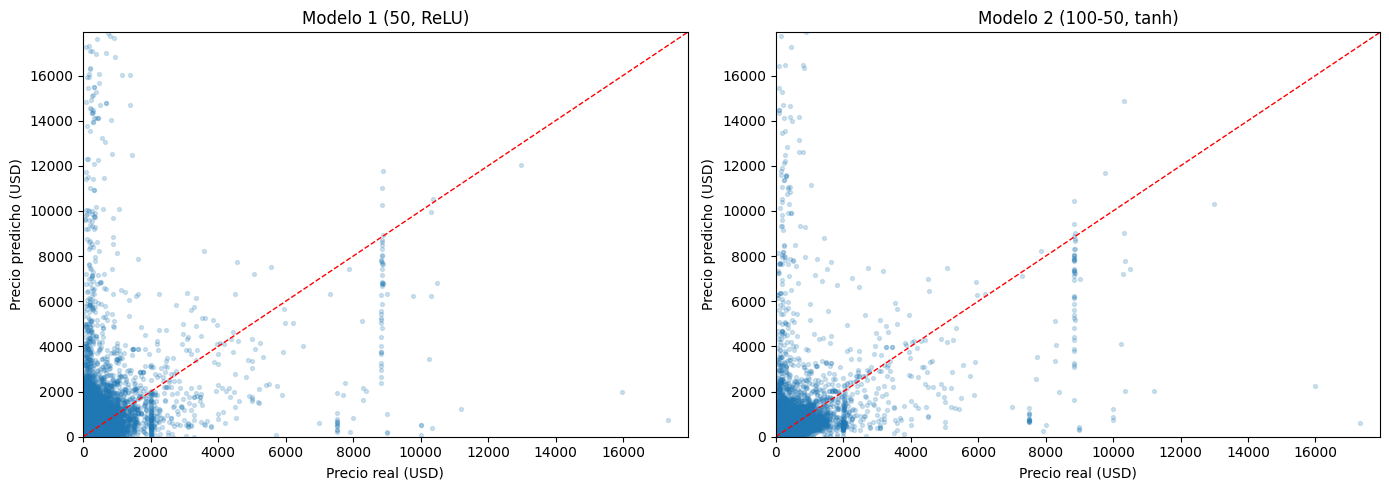

In [66]:
# Visualización: precio real vs precio predicho para cada modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, titulo in [
    (axes[0], y1_pred_1, "Modelo 1 (50, ReLU)"),
    (axes[1], y1_pred_2, "Modelo 2 (100-50, tanh)"),
]:
    ax.scatter(y1_test, y_pred, alpha=0.2, s=8)
    lim = [0, np.percentile(y1_test, 99)]
    ax.plot(lim, lim, 'r--', linewidth=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Precio real (USD)")
    ax.set_ylabel("Precio predicho (USD)")
    ax.set_title(titulo)

plt.tight_layout()
plt.show()

**Topologías, funciones de activación y resultados de los modelos de regresión (inciso 10):**

| Modelo | Capas ocultas | Activación | Solver | Tiempo aprox. | MAE | RMSE | R² |
|--------|---------------|------------|--------|---------------|-----|------|-----|
| 1 (simple)   | (50,)     | ReLU | Adam | ~12 s | ~736 | ~2547 | ~0.634 |
| 2 (complejo) | (100, 50) | tanh | Adam | ~18 s | ~528 | ~2271 | ~0.709 |

El modelo complejo supera al simple en todas las métricas y, a diferencia del caso de clasificación, sí justifica el costo computacional adicional. El R² ≈ 0.71 indica que el modelo explica el 71% de la varianza del precio en datos no vistos, una mejora estructural respecto al ~0.38 que se obtenía con el set de 5 variables.

Se reitera la condición de comparabilidad: ambos modelos comparten el mismo conjunto de entrenamiento y prueba que los modelos de clasificación (mismo `random_state`, mismo `stratify=y`, mismas 15 variables predictoras). En los incisos 14–16 se replicarán los mejores algoritmos de los Laboratorios 7 y 8 con este mismo set para garantizar una comparación válida bajo las mismas condiciones.

### 11. Comparación de los dos modelos

### 12. Análisis de sobreajuste y curva de aprendizaje